# Dataset Overview
This is the exploration textbook, in which exploration is the only thing that happens here.
The goal is to have the dataset undergo Descriptive Statistics, and to figure out what needs to be done for the dataset to be usable for machine learning.

## The Libraries
These are the libraries that will be used in this textbook, you may fun each at a time or all at once.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

I will first load the training and testing datasets using pandas (as pd).
The training dataset will be used to develop the model, while the testing dataset will be used for final evaluation.
Assigning target variable and features into variables for training model.

In [11]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


While the training data has the target column "health_condition", the testing dataset does not.
The dataset has both categorical and numerical variables, and all of the columns (other than id and health_condition) are caracteristics related to a healthy lifestyle.

## Dataset Size

Before analyzing the dataset, I will first check if there are enough observations to train a model on this dataset.
I am looking for > 1000 observations. Additionally, there is a curiosity on how big the dataset is, especially if there are values that have to be removed.

In [5]:
train.shape

(690088, 15)

The training dataset has 690088 observations and 15 columns.
This is plenty for training a multi-class classification model.

# Dataset Variables
I will be using .info() to get more information about the dataset's variables, and then .value_counts() on individual variables for more information.

In [25]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

There are 14 columns in total. 7 categorical and 7 quantitative variables, if you count "id".

## Categorical Variables
Bellow, we will look into the categorical variables in this dataset

### Health Condition
The target variable. There are no nulls in this variable, and it has three options: unhealthy, at-risk, and fit.
Notably, majority of the counts are in the "at-risk" category. and "fit" has the least counts

In [27]:
train["health_condition"].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

### Diet Type
There are three categories for diet type: vegan, balanced, and non-vegan.
There is an overrepresentation of vegans in the dataset, vegans are rarer than non-vegans normally. Howerver, all variables are almost evenly distributed. "non-veg" has the lowest count.
There are null entries for this category.

In [28]:
train["diet_type"].value_counts()

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64

In [33]:
train["diet_type"].unique()

<StringArray>
['veg', 'non-veg', 'balanced', nan]
Length: 4, dtype: str

### Stress Level
There are three categories for stress level: low, medium, and high. "medium" is the category with the most counts, with almost 100,000 counts more than "high", or "low". "low" is the category with the least counts.
There are null entries for this category.

In [29]:
train["stress_level"].value_counts()

stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64

In [32]:
train["stress_level"].unique()

<StringArray>
['high', 'low', nan, 'medium']
Length: 4, dtype: str

### Sleep Quality
There are three categories for sleep quality: poor, average, and good. "average" was the category with the most counts, "good" was the least common entry.
There are null entries for this category.

In [30]:
train["sleep_quality"].value_counts()

sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64

In [34]:
train["sleep_quality"].unique()

<StringArray>
['average', 'poor', nan, 'good']
Length: 4, dtype: str

### Physical Activity level
There are three categories for physical activity level: sedentary, moderate, and active. "moderate" has the most counts, and "active" has the least.
There are null entries for this category.

In [31]:
train["physical_activity_level"].value_counts()

physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64

In [35]:
train["physical_activity_level"].unique()

<StringArray>
['sedentary', 'moderate', 'active', nan]
Length: 4, dtype: str

### Smoker or Drinker
There are three categories for smoker or drinker: no, occasional, and yes. "yes" has the most counts, while "occasional" has the least.
there are null entries for this category

In [36]:
train["smoking_alcohol"].value_counts()

smoking_alcohol
yes           223730
no            219791
occasional    217985
Name: count, dtype: int64

In [37]:
train["smoking_alcohol"].unique()

<StringArray>
['yes', 'occasional', nan, 'no']
Length: 4, dtype: str

### Gender
There are three categories for gender: other, female, and male. "male" is the category with the most counts, while "other" has the least.
there are null entries for this category.

In [38]:
train["gender"].value_counts()

gender
male      237756
female    224016
other     206943
Name: count, dtype: int64

In [39]:
train["gender"].unique()

<StringArray>
['female', 'other', 'male', nan]
Length: 4, dtype: str


### Summary Categorical Variables
- There are 7 categorical variables. 
- There are null values for all categorical variables but "health condition"
- The dataset seems to overrepresent 'unhealthier' individuals, with more smokers than non smokers, and more individuals with a sedentary livestyle.
- Cleaning and encoding will be necessary.

## Class Distribution

A balanced target variable is important for classification. I will visualize the target variable to see if there are any glaring issues. Additionally, I will see the percentages after

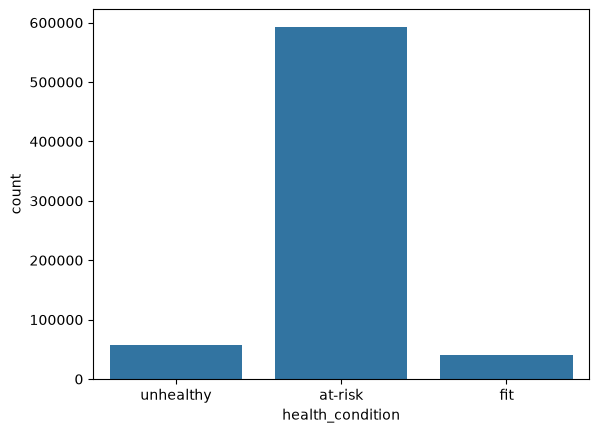

In [12]:
sns.countplot(data=train, x="health_condition")
plt.show()

In [13]:
train["health_condition"].value_counts(normalize=True) * 100

health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64

There seems to be an overrepresentation of the "at-risk" category in health_condition. A model would need to be rewarded more for classifying "fit" or "unhealthy" right more than "at-risk".